<a href="https://colab.research.google.com/github/tasnimmahin21-sudo/Database-and-Analytics-Assignment/blob/main/R_SQL_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Merge structured operational records using SQL inside R to identify hub capacity bottlenecks.

In [ ]:
# Enable R magic to run R code within the Python notebook
%load_ext rpy2.ipython

import pandas as pd

# 1. Define your exact GitHub Raw Base URL
base_url = 'https://raw.githubusercontent.com/tasnimmahin21-sudo/Database-and-Analytics-Assignment/refs/heads/main/'

# 2. Load datasets directly from your repository
hubs_df = pd.read_csv(base_url + 'hubs.csv')
orders_df = pd.read_csv(base_url + 'orders.csv')
deliveries_df = pd.read_csv(base_url + 'deliveries.csv')

# Clean data
hubs_df['zone'] = hubs_df['zone'].str.upper()
orders_df['pickup_zone'] = orders_df['pickup_zone'].str.upper()

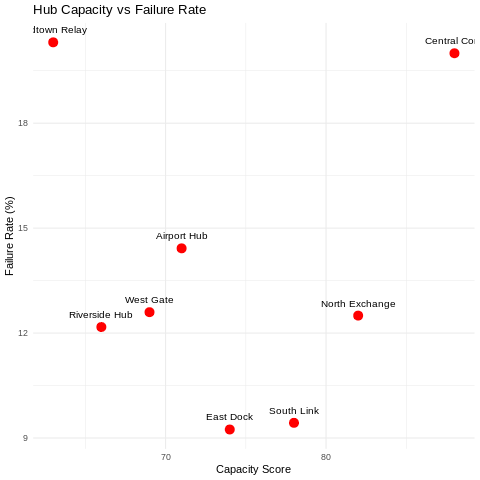

In [ ]:
%%R -i hubs_df,orders_df,deliveries_df
# Install and load R packages quietly
install.packages("sqldf", quiet=TRUE)
install.packages("ggplot2", quiet=TRUE)
library(sqldf)
library(ggplot2)

# Pull the Python dataframes into the R environment
hubs_r <- hubs_df
orders_r <- orders_df
deliveries_r <- deliveries_df

# SQL Query to analyze hub capacity versus delivery success
hub_performance_query <- "
  SELECT
    h.hub_name,
    h.capacity_score,
    COUNT(d.delivery_id) as total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) as failed_deliveries
  FROM hubs_r h
  JOIN deliveries_r d ON h.hub_id = d.hub_id
  GROUP BY h.hub_name, h.capacity_score
  ORDER BY failed_deliveries DESC
"
hub_stats <- sqldf(hub_performance_query)
hub_stats$failure_rate <- (hub_stats$failed_deliveries / hub_stats$total_deliveries) * 100

# R Analytics Visualisation
ggplot(hub_stats, aes(x=capacity_score, y=failure_rate, label=hub_name)) +
  geom_point(color="red", size=4) +
  geom_text(vjust=-1.5, hjust=0.5, size=3.5) +
  theme_minimal() +
  labs(title="Hub Capacity vs Failure Rate", x="Capacity Score", y="Failure Rate (%)")